# E‑commerce Product Analysis

Đánh giá người dùng so với hiệu quả bán hàng: Lộc - có dùng ML

- **Câu hỏi 1:** Tác động của Điểm số và Số lượng đánh giá đến Doanh thu
- **Câu hỏi 2:** Phân khúc chiến lược sản phẩm dựa trên tương tác cộng đồng

## Setup
Load libraries and configure plotting.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid") # Set theme hiện đại cho toàn bộ charts

## Load and Prepare Data

In [11]:
# 1. Load Data
df_product = pd.read_csv("../data/products.csv")
df_review = pd.read_csv("../data/reviews.csv")

# 2. Xử lý Doanh thu & Tương tác
df_product["revenue"] = df_product["price"] * df_product["sold_count"]

review_engagement = (
    df_review.groupby("product_id")["like_count"]
    .sum()
    .reset_index()
    .rename(columns={"like_count": "total_review_likes"})
)

df_main = pd.merge(df_product, review_engagement, on="product_id", how="left")
df_main["total_review_likes"] = df_main["total_review_likes"].fillna(0)

df_clean = df_main[(df_main["sold_count"] > 0) & (df_main["review_count"] > 0)].copy()

# Câu hỏi 1

## Tác động của Điểm số và Số lượng đánh giá đến Doanh thu

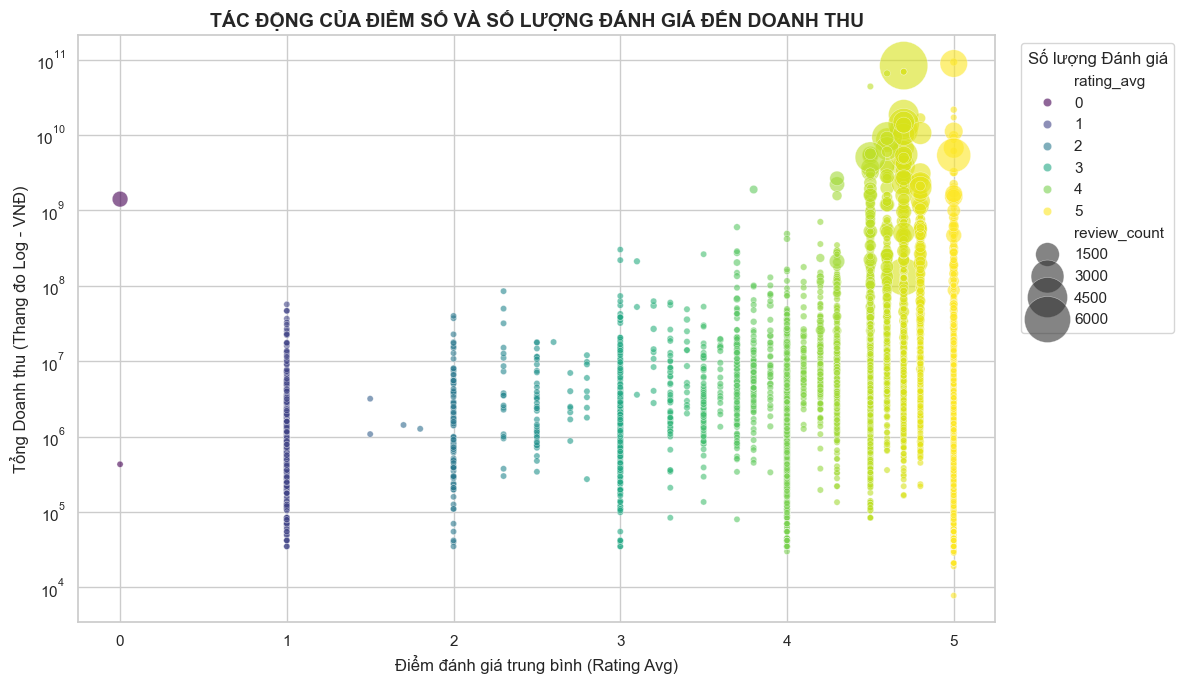

Hệ số tương quan với Doanh thu:
 rating_avg     -0.074557
review_count    0.652835
revenue         1.000000
Name: revenue, dtype: float64


In [23]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_clean,
    x="rating_avg",
    y="revenue",
    size="review_count",
    sizes=(20, 1200), 
    alpha=0.6,
    hue="rating_avg",
    palette="viridis",
    edgecolor="w"
)

plt.yscale("log")
plt.xlabel("Điểm đánh giá trung bình (Rating Avg)", fontsize=12)
plt.ylabel("Tổng Doanh thu (Thang đo Log - VNĐ)", fontsize=12)
plt.title("TÁC ĐỘNG CỦA ĐIỂM SỐ VÀ SỐ LƯỢNG ĐÁNH GIÁ ĐẾN DOANH THU", fontsize=14, fontweight="bold")

plt.legend(title="Số lượng Đánh giá", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Tính hệ số tương quan Spearman
corr_q1 = df_clean[["rating_avg","review_count","revenue"]].corr(method="spearman")
print("Hệ số tương quan với Doanh thu:\n", corr_q1["revenue"])

- Rating gần như không có tác động đến Revenue.
- Số lượng đánh giá lại có sự tương quan dương rất mạnh với doanh thu (Spearman = ~0.65). Những món hàng lợi nhuận cao đều tập trung ở dải 4.5 - 4.9 sao và sở hữu hàng ngàn lượt đánh giá.

=> Các sản phẩm được mua thường được dựa vào số lượng reivew hơn là lượng rating

# Câu hỏi 2

## Phân khúc chiến lược sản phẩm dựa trên tương tác cộng đồng

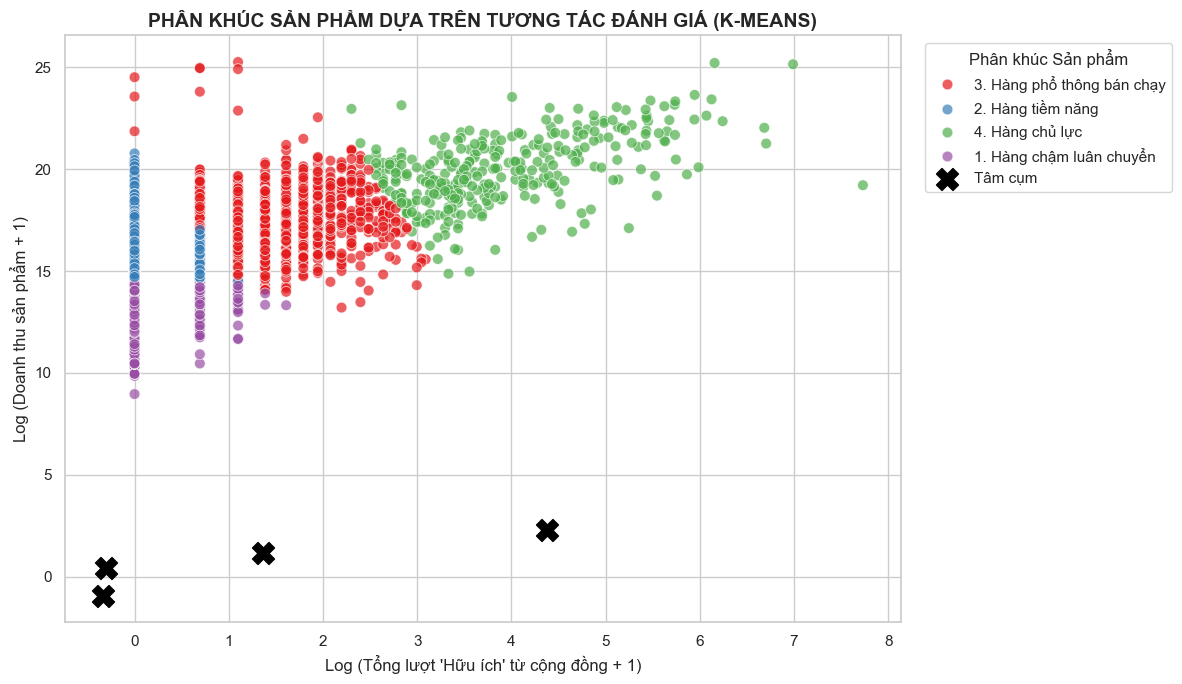

In [24]:
# 1. Chuẩn bị dữ liệu ML
df_ml = df_clean[df_clean["revenue"] > 0].copy()
df_ml["log_revenue"] = np.log1p(df_ml["revenue"])
df_ml["log_likes"] = np.log1p(df_ml["total_review_likes"])

X = df_ml[["log_likes","log_revenue"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Huấn luyện K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_ml["cluster"] = kmeans.fit_predict(X_scaled)

# 3. Gán nhãn phân khúc (Sắp xếp theo thứ tự doanh thu tăng dần)
cluster_means = df_ml.groupby('cluster')['log_revenue'].mean().sort_values()
cluster_mapping = {
    cluster_means.index[0]: '1. Hàng chậm luân chuyển', 
    cluster_means.index[1]: '2. Hàng tiềm năng', 
    cluster_means.index[2]: '3. Hàng phổ thông bán chạy', 
    cluster_means.index[3]: '4. Hàng chủ lực'
}
df_ml['cluster_name'] = df_ml['cluster'].map(cluster_mapping)

# 4. Trực quan hóa
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_ml, x="log_likes", y="log_revenue", 
    hue="cluster_name", palette="Set1", alpha=0.7, s=60, edgecolor="w"
)

centroids = kmeans.cluster_centers_
plt.scatter(centroids[:,0], centroids[:,1], marker="X", s=250, c="black", label="Tâm cụm")

plt.xlabel("Log (Tổng lượt 'Hữu ích' từ cộng đồng + 1)", fontsize=12)
plt.ylabel("Log (Doanh thu sản phẩm + 1)", fontsize=12)
plt.title("PHÂN KHÚC SẢN PHẨM DỰA TRÊN TƯƠNG TÁC ĐÁNH GIÁ (K-MEANS)", fontsize=14, fontweight="bold")

plt.legend(title="Phân khúc Sản phẩm", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Dựa trên thuật toán phân cụm, các sản phẩm được chia thành 4 nhóm đặc trưng:
- Loại 1 - Hàng chậm luân chuyển: Chiếm đa số, doanh thu rất thấp và không ghi nhận sự tương tác từ cộng đồng tại phần đánh giá.
- Loại 2 - Hàng tiềm năng: Doanh thu bắt đầu nhỉnh hơn nhưng cộng đồng vẫn chưa thực sự quan tâm hoặc phản hồi lại các bình luận.
- Loại 3 - Hàng phổ thông bán chạy: Nhóm sản phẩm ghi nhận lượt bán cao nhưng mức độ tương tác đánh giá cực thấp. Đây thường là các mặt hàng thiết yếu, giá rẻ, người dùng có xu hướng mua nhanh mà không cần tham khảo sâu.
- Loại 4 - Hàng chủ lực: Nhóm tinh hoa mang lại nguồn doanh thu cao nhất. Đặc điểm cốt lõi là các sản phẩm này sở hữu những bài review có chất lượng cao, thu hút lượng lớn lượt "Hữu ích" từ người dùng khác.

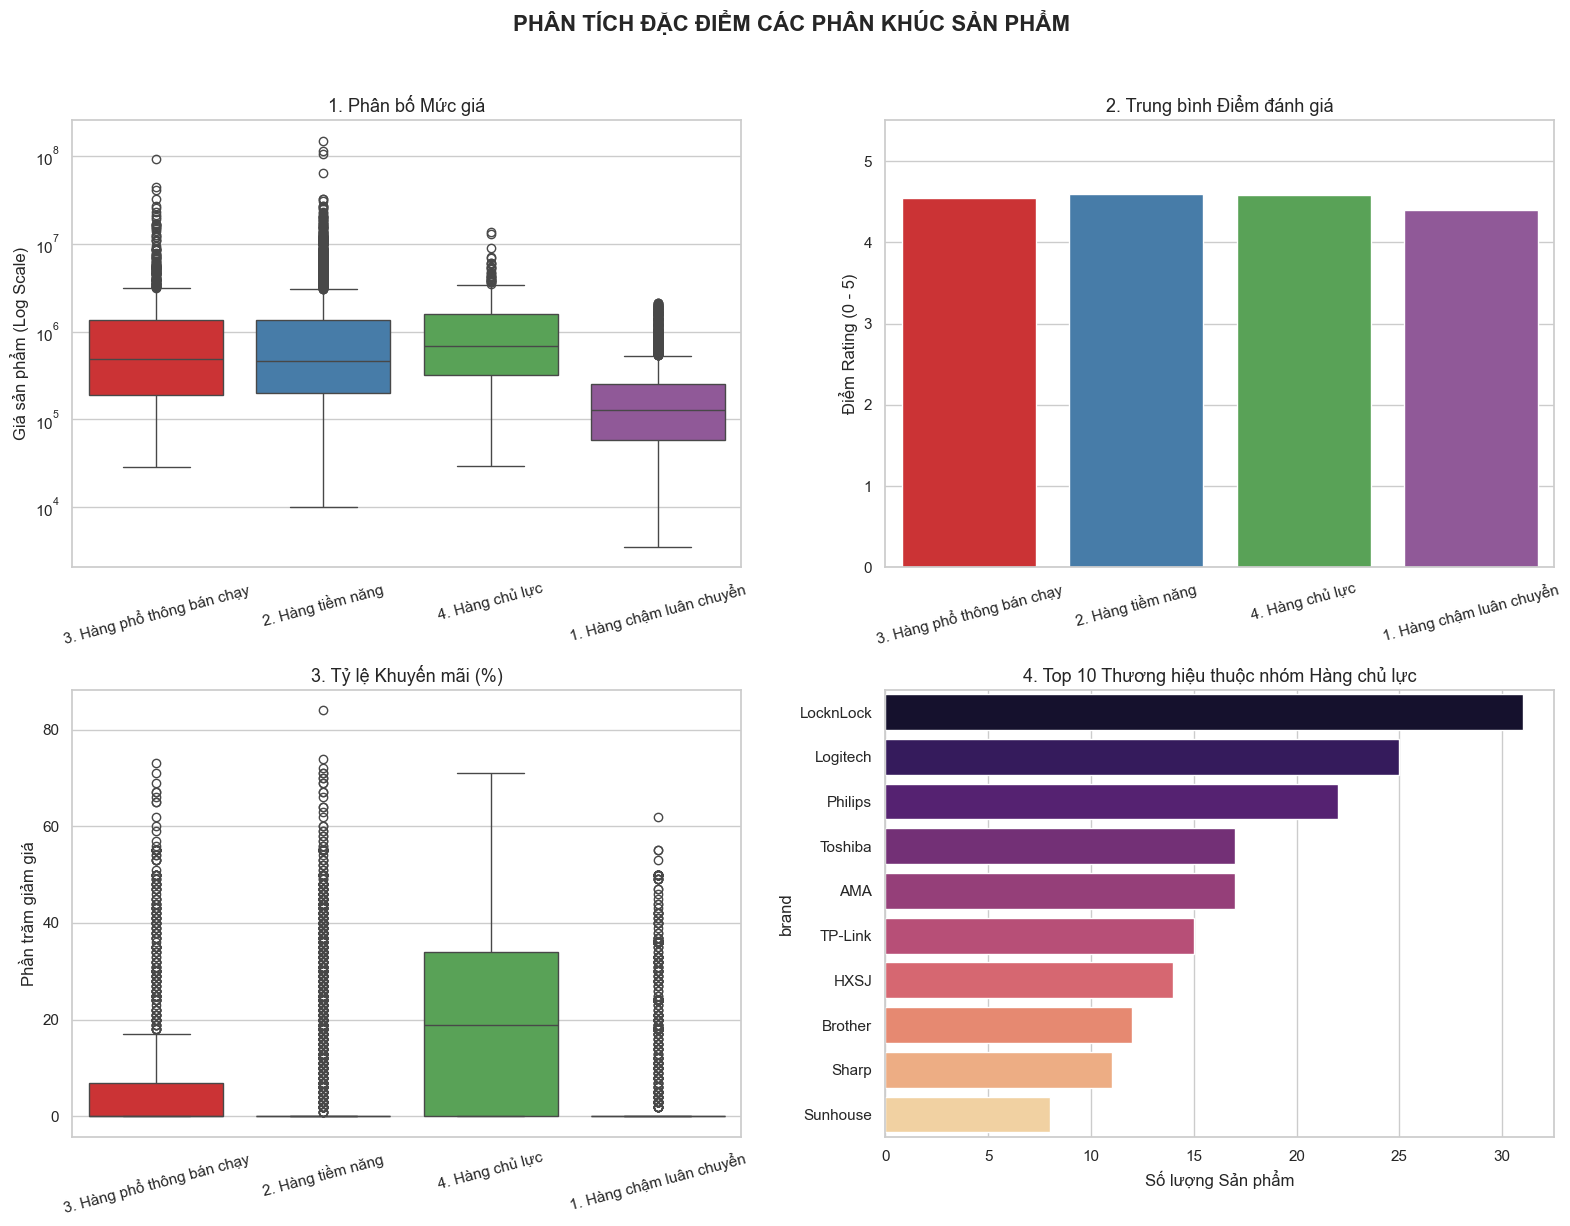

--- BẢNG PHÂN TÍCH ĐẶC ĐIỂM 4 NHÓM SẢN PHẨM ---
                            Giá trung vị (VNĐ)  Rating TB  \
cluster_name                                                
1. Hàng chậm luân chuyển              129000.0       4.40   
2. Hàng tiềm năng                     458000.0       4.59   
3. Hàng phổ thông bán chạy            490000.0       4.54   
4. Hàng chủ lực                       687500.0       4.58   

                            Giảm giá Trung vị (%)  Giảm giá TB (%)  
cluster_name                                                        
1. Hàng chậm luân chuyển                      0.0             4.11  
2. Hàng tiềm năng                             0.0             5.29  
3. Hàng phổ thông bán chạy                    0.0             8.14  
4. Hàng chủ lực                              19.0            18.96  


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('PHÂN TÍCH ĐẶC ĐIỂM CÁC PHÂN KHÚC SẢN PHẨM', fontsize=16, fontweight='bold', y=1.02)

# Biểu đồ 1: Phân bố giá
sns.boxplot(data=df_ml, x='cluster_name', y='price', palette='Set1', ax=axes[0,0])
axes[0,0].set_yscale('log')
axes[0,0].set_title('1. Phân bố Mức giá', fontsize=13)
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Giá sản phẩm (Log Scale)')
axes[0,0].tick_params(axis='x', rotation=15)

# Biểu đồ 2: Phân bố Rating
sns.barplot(data=df_ml, x='cluster_name', y='rating_avg', palette='Set1', ax=axes[0,1], errorbar=None)
axes[0,1].set_title('2. Trung bình Điểm đánh giá', fontsize=13)
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Điểm Rating (0 - 5)')
axes[0,1].set_ylim(0, 5.5)
axes[0,1].tick_params(axis='x', rotation=15)

# Biểu đồ 3: Khuyến mãi
sns.boxplot(data=df_ml, x='cluster_name', y='discount_percent', palette='Set1', ax=axes[1,0])
axes[1,0].set_title('3. Tỷ lệ Khuyến mãi (%)', fontsize=13)
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Phần trăm giảm giá')
axes[1,0].tick_params(axis='x', rotation=15)

# Biểu đồ 4: Thương hiệu Hàng chủ lực
df_stars = df_ml[(df_ml['cluster_name'] == '4. Hàng chủ lực') & (df_ml['brand'].notna())]
top_brands = df_stars['brand'].value_counts().head(10)
sns.barplot(x=top_brands.values, y=top_brands.index, palette='magma', ax=axes[1,1])
axes[1,1].set_title('4. Top 10 Thương hiệu thuộc nhóm Hàng chủ lực', fontsize=13)
axes[1,1].set_xlabel('Số lượng Sản phẩm')

plt.tight_layout()
plt.show()

# ==========================================
# BẢNG THỐNG KÊ CHI TIẾT CÁC PHÂN KHÚC
# ==========================================
print("--- BẢNG PHÂN TÍCH ĐẶC ĐIỂM 4 NHÓM SẢN PHẨM ---")

# Dùng groupby để tính toán các chỉ số trung bình và trung vị
summary_table = df_ml.groupby('cluster_name').agg({
    'price': 'median',               # Giá lấy trung vị để tránh nhiễu
    'rating_avg': 'mean',            # Rating lấy trung bình
    'discount_percent': ['median', 'mean'] # Lấy cả 2 để xem độ lệch của Khuyến mãi
}).round(2)

# Đổi tên cột cho đẹp
summary_table.columns = ['Giá trung vị (VNĐ)', 'Rating TB', 'Giảm giá Trung vị (%)', 'Giảm giá TB (%)']

print(summary_table)

- Về Điểm số: Cả 4 phân khúc đều duy trì mức điểm trung bình ổn định (4.4 - 4.6 sao). Điều này cho thấy điểm số cao là yêu cầu cơ bản, không tạo ra lợi thế cạnh tranh cốt lõi.
- Về Giá và Khuyến mãi: Nhóm "Hàng chủ lực" có mức giá phân bổ cao hơn, và biết kết hợp 2 thứ
    + Sự uy tín (Review chất lượng) 
    + Mức giá hấp dẫn (Giảm giá trung vị cao nhất, dao động đều ở mức 20-35%).
- Về Văn bản đánh giá: Các bài đánh giá nhận được nhiều lượt "Hữu ích" không phải là những câu ngắn gọn. Chúng đòi hỏi độ dài chi tiết (hiển thị trên biểu đồ phân tán -> oi khúc này kh biết nói sao, chắc phụ thuộc vào brand nữa...